In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulate_stochastic_qif(I_app, I_syn_0, sigma, theta, N, dt, V_th, V_reset):
    V = np.zeros(N)
    I_syn = np.zeros(N)
    V[0] = V_reset
    I_syn[0] = I_syn_0
    spike_times = []
    
    for i in range(N - 1):
        # Deterministic drift
        V[i+1] = V[i] + (V[i]**2 + I_app + I_syn[i]) * dt
        # Stochastic diffusion (Euler-Maruyama step)
        drift = - theta * I_syn[i] * dt
        diffusion = sigma * np.sqrt(dt) * np.random.randn()
        
        I_syn[i+1] = I_syn[i] + drift + diffusion
        
        # Reset condition and spike logging
        if V[i+1] >= V_th:
            V[i+1] = V_reset
            V[i] = V_th # Pin peak for plotting
            spike_times.append(time[i])
            
    return V, I_syn, np.array(spike_times)

In [3]:
# 1. Define Model Parameters
I_syn_0 = 0.0      # Initial synaptic current
I_app_sub = -0.5    # Subthreshold current (for noise-induced spiking)
I_app_sup = 1.5     # Suprathreshold current (for ISI histogram)
theta = 0.1         # Synaptic time constant
sigmas = [2, 5]        # Noise intensity
V_th = 10.0         # Spike threshold
V_reset = -10.0     # Reset potential

# 2. Simulation Parameters
dt = 0.001
T_max = 50.0        # Longer time to gather enough spikes for the histogram
time = np.arange(0, T_max, dt)
N = len(time)

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bielb\AppData\Local\Temp\ipykernel_9040\1732591669.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title(f'Noise-Induced Spiking ($I_{{app}}={I_app_sub}$, $\sigma={sigma}$)')
C:\Users\bielb\AppData\Local\Temp\ipykernel_9040\1732591669.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title(f'ISI Histograma ($I_{{app}}={I_app_sup}$, $\sigma={sigma}$)')


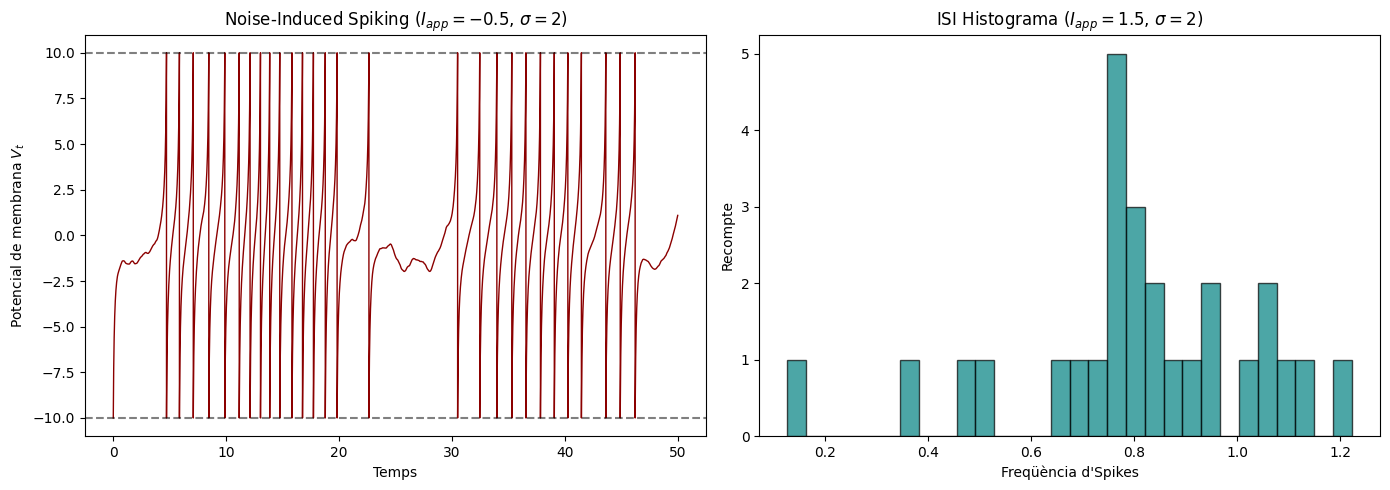

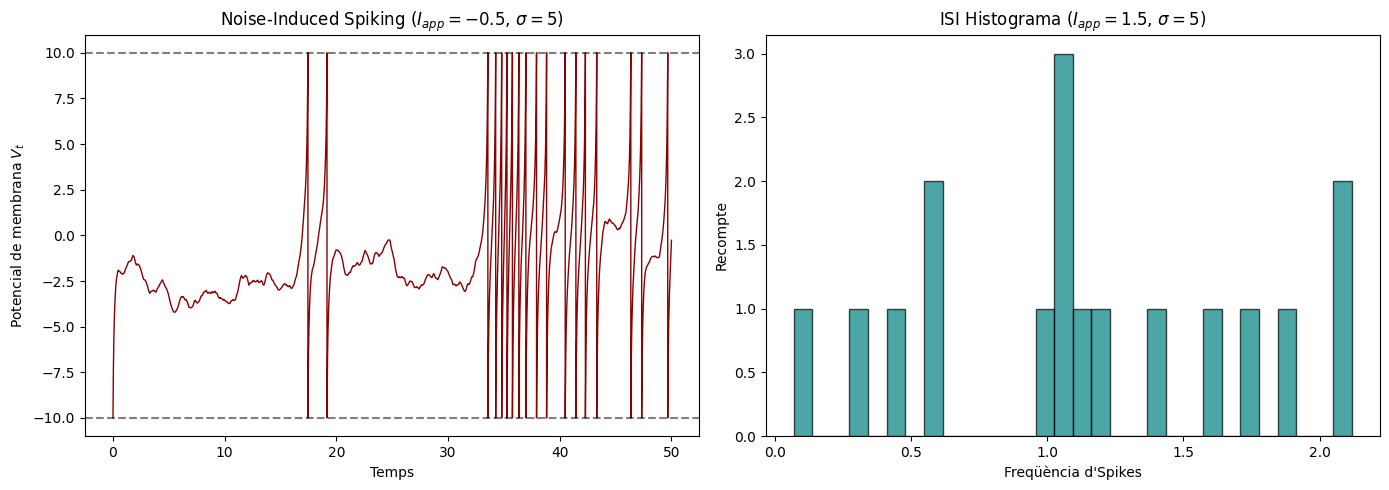

In [7]:
np.random.seed(123)

for sigma in sigmas:
    # 3. Run Simulations
    V_sub, I_syn_sub, spikes_sub = simulate_stochastic_qif(I_app_sub, I_syn_0,sigma, theta, N, dt, V_th, V_reset)
    V_sup, I_syn_sup, spikes_sup = simulate_stochastic_qif(I_app_sup, I_syn_0,sigma, theta, N, dt, V_th, V_reset)

    # Calculate ISIs (differences between consecutive spike times)
    freq_instantania = 1.0 / np.diff(spikes_sub)
    freq_mitjana = len(spikes_sub) / (time[-1] - time[0])

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: Noise-induced spiking
    ax1.plot(time, V_sub, color='darkred', lw=1)
    ax1.axhline(V_th, color='k', linestyle='--', alpha=0.5)
    ax1.axhline(V_reset, color='k', linestyle='--', alpha=0.5)
    ax1.set_title(f'Noise-Induced Spiking ($I_{{app}}={I_app_sub}$, $\sigma={sigma}$)')
    ax1.set_xlabel('Temps')
    ax1.set_ylabel('Potencial de membrana $V_t$')

    # Panel B: ISI Histogram
    ax2.hist(freq_instantania, bins=30, color='teal', edgecolor='black', alpha=0.7)
    ax2.set_title(f'ISI Histograma ($I_{{app}}={I_app_sup}$, $\sigma={sigma}$)')
    ax2.set_xlabel('Freqüència d\'Spikes')
    ax2.set_ylabel('Recompte')

    plt.tight_layout()
    plt.show()

In [8]:
theta_gt = 1
sigma_gt = 2.0
I_app = 0.5
I_syn_0 = 0.0
V_th = 10.0
V_reset = -10.0

dt = 0.001
T_max = 50.0
time = np.arange(0, T_max, dt)
N = len(time)

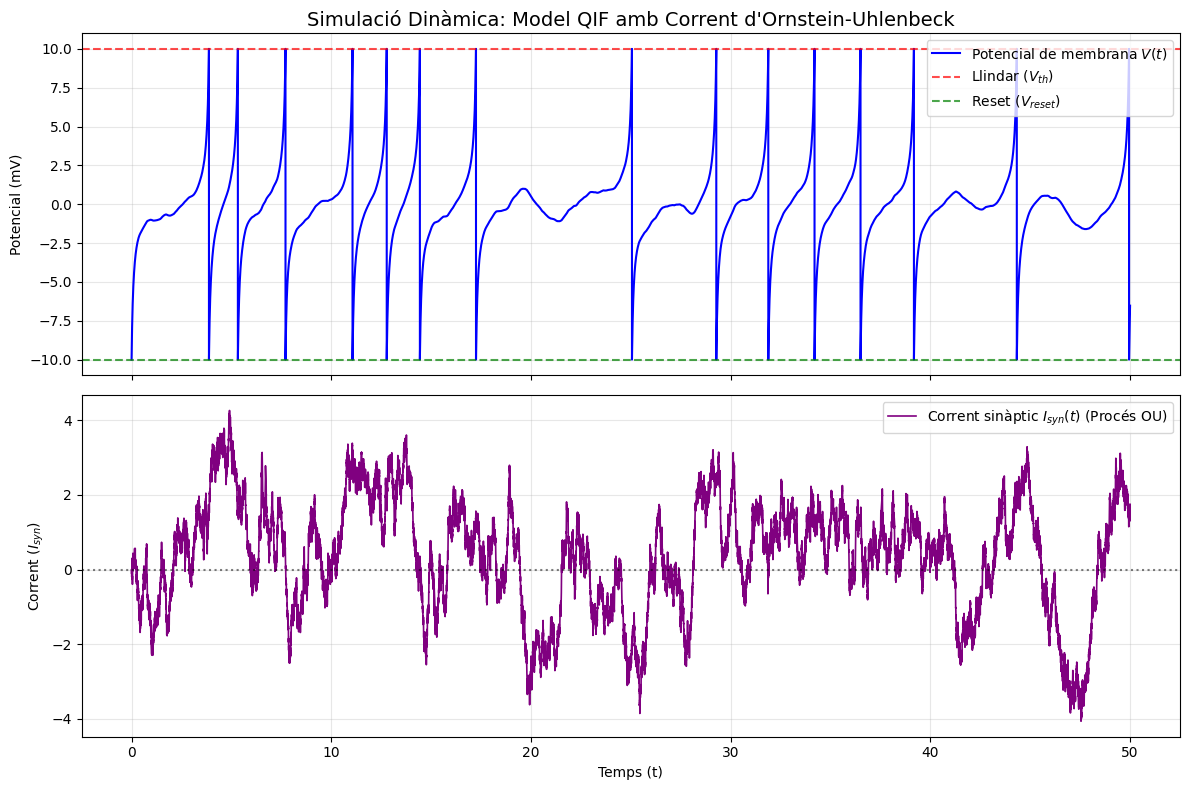

In [9]:
np.random.seed(123)
# 1. Definim el vector de temps basat en el nombre de passos N i el pas dt
time = np.arange(N) * dt

# 2. Executem la simulació rebent els 3 valors de retorn (assegura't d'haver canviat la cel·la 2)
V_gt, I_syn_gt, Spike_times_gt = simulate_stochastic_qif(I_app, I_syn_0, sigma_gt, theta_gt, N, dt, V_th, V_reset)

# 3. Creem la figura amb 2 subplots verticals que comparteixen l'eix X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- PANELL SUPERIOR: Potencial de membrana V(t) ---
ax1.plot(time, V_gt, label='Potencial de membrana $V(t)$', color='b', linewidth=1.5)
ax1.axhline(V_th, color='r', linestyle='--', alpha=0.7, label='Llindar ($V_{th}$)')
ax1.axhline(V_reset, color='g', linestyle='--', alpha=0.7, label='Reset ($V_{reset}$)')
ax1.set_ylabel('Potencial (mV)')
ax1.set_title('Simulació Dinàmica: Model QIF amb Corrent d\'Ornstein-Uhlenbeck', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- PANELL INFERIOR: Corrent sinàptic I_syn(t) ---
ax2.plot(time, I_syn_gt, label='Corrent sinàptic $I_{syn}(t)$ (Procés OU)', color='purple', linewidth=1.2)
ax2.axhline(0, color='black', linestyle=':', alpha=0.5) # Línia de referència a zero
ax2.set_xlabel('Temps (t)')
ax2.set_ylabel('Corrent ($I_{syn}$)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Ajustem l'espaiat perquè no se superposin els textos
plt.tight_layout()
plt.show()

In [13]:
np.random.seed(123)
# 1. Simulem el model (ara la funció ens retorna també el procés I_syn_gt)
V_gt, I_syn_gt, Spike_times_gt = simulate_stochastic_qif(I_app, I_syn_0, sigma_gt, theta_gt, N, dt, V_th, V_reset)

# 2. Preparem els vectors (Això evita fer un bucle 'for' i és mil vegades més ràpid)
I_k = I_syn_gt[:-1]         # Correspon a I_k (de l'element 0 al N-2)
I_k_plus_1 = I_syn_gt[1:]   # Correspon a I_{k+1} (de l'element 1 al N-1)
n_increments = N - 1        # Nombre total d'increments

# 3. Càlcul de l'estimador de theta (\hat{\theta})
theta_hat = np.sum(I_k * (I_k - I_k_plus_1)) / (dt * np.sum(I_k**2))

# 4. Càlcul de l'estimador de sigma^2 i sigma (\hat{\sigma}^2 i \hat{\sigma})
sigma_squared_hat = np.sum((I_k_plus_1 - I_k + theta_hat * I_k * dt)**2) / (n_increments * dt)
sigma_hat = np.sqrt(sigma_squared_hat)

In [19]:
Error_theta = np.abs(theta_hat - theta_gt)
Error_sigma = np.abs(sigma_hat - sigma_gt)

print(f"Paràmetre theta real: {theta_gt:.4f}, Estimat: {theta_hat:.4f}, Error absolt: {Error_theta:.4f}")
print(f"Paràmetre sigma real: {sigma_gt:.4f}, Estimat: {sigma_hat:.4f}, Error absolut: {Error_sigma:.4f}")

Paràmetre theta real: 1.0000, Estimat: 0.8225, Error absolt: 0.1775
Paràmetre sigma real: 2.0000, Estimat: 1.9999, Error absolut: 0.0001
